In [1]:
#Install required libraries
!pip install --quiet tensorflow==2.12.0 scikit-learn pandas matplotlib shap==0.41.0 joblib tqdm
print("Install complete")


ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0
Install complete


In [3]:
#Mount Google Drive and create folder structure
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

BASE = '/content/drive/My Drive/TimeSeries_LSTM_Project'
for sub in ['data', 'notebooks', 'outputs']:
    os.makedirs(os.path.join(BASE, sub), exist_ok=True)

print(" Base folder created at:", BASE)
print("Upload your dataset to:", os.path.join(BASE, 'data'))


Mounted at /content/drive
 Base folder created at: /content/drive/My Drive/TimeSeries_LSTM_Project
Upload your dataset to: /content/drive/My Drive/TimeSeries_LSTM_Project/data


In [14]:
#Load dataset (with row reduction for faster training)
import pandas as pd
import os

DATA_CSV = os.path.join(BASE, 'data', 'jena_climate_2009_2016.csv')

if not os.path.exists(DATA_CSV):
    raise FileNotFoundError("❌ Dataset not found. Upload CSV to /data folder.")
else:
    df = pd.read_csv(DATA_CSV)
    print("Original full dataset shape:", df.shape)

    df = df.head(150000)
    print("Reduced dataset shape:", df.shape)

    display(df.head())


Original full dataset shape: (420551, 15)
Reduced dataset shape: (150000, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [15]:
#Choose 5+ features and target
print("Columns available:\n", df.columns.tolist())
print("Total rows:", len(df))

FEATURES = [
    'p (mbar)',
    'T (degC)',
    'rho (g/m**3)',
    'wv (m/s)',
    'max. wv (m/s)'
]

TARGET = 'T (degC)'

for c in FEATURES + [TARGET]:
    if c not in df.columns:
        raise ValueError(f"Column {c} not found. Update FEATURES list.")

print("Using features:", FEATURES)
print("Target:", TARGET)


Columns available:
 ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total rows: 150000
Using features: ['p (mbar)', 'T (degC)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)']
Target: T (degC)


In [16]:
#Preprocessing and sequence creation
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Clean & scale
data = df[FEATURES].copy().fillna(method='ffill').fillna(method='bfill')
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.values)

# Sliding window
def create_sequences(X, target_index, seq_len=72, horizon=1):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - horizon + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(X[i+seq_len+horizon-1, target_index])
    return np.array(Xs), np.array(ys)

SEQ_LEN = 72
HORIZON = 1
target_idx = FEATURES.index(TARGET)

X, y = create_sequences(data_scaled, target_idx, seq_len=SEQ_LEN, horizon=HORIZON)

print("X shape:", X.shape)
print("y shape:", y.shape)

joblib.dump(scaler, os.path.join(BASE, 'outputs', 'scaler.save'))


/tmp/ipython-input-2133130005.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = df[FEATURES].copy().fillna(method='ffill').fillna(method='bfill')


X shape: (149928, 72, 5)
y shape: (149928,)


['/content/drive/My Drive/TimeSeries_LSTM_Project/outputs/scaler.save']

In [17]:
#Define CV splitter + metrics
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

def rmse(a, b):
    return math.sqrt(mean_squared_error(a, b))

tscv = TimeSeriesSplit(n_splits=3)

print("Total sequences:", X.shape[0])


Total sequences: 149928


In [18]:
#Build LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm(seq_len, n_features, units=32, dropout=0.2):
    model = Sequential([
        LSTM(units, input_shape=(seq_len, n_features)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [19]:
#FAST Hyperparameter tuning with TimeSeriesSplit
import pandas as pd
from tqdm.notebook import tqdm

param_grid = {
    'seq_len': [48],
    'units': [16, 32],
    'dropout': [0.1, 0.2],
    'batch_size': [32],
    'epochs': [10]
}

results = []

for seq_len in param_grid['seq_len']:
    Xtemp, ytemp = create_sequences(data_scaled, target_idx, seq_len=seq_len, horizon=HORIZON)

    for units in param_grid['units']:
        for dropout in param_grid['dropout']:

            fold_maes = []
            fold_rmses = []

            for train_idx, val_idx in tscv.split(Xtemp):
                X_train, y_train = Xtemp[train_idx], ytemp[train_idx]
                X_val, y_val = Xtemp[val_idx], ytemp[val_idx]

                model = build_lstm(seq_len, X_train.shape[2], units=units, dropout=dropout)
                es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
                model.fit(X_train, y_train, validation_data=(X_val, y_val),
                          epochs=10, batch_size=32, callbacks=[es], verbose=0)

                preds = model.predict(X_val).ravel()

                fold_maes.append(mean_absolute_error(y_val, preds))
                fold_rmses.append(rmse(y_val, preds))

            results.append({
                'seq_len': seq_len,
                'units': units,
                'dropout': dropout,
                'mae_mean': np.mean(fold_maes),
                'rmse_mean': np.mean(fold_rmses)
            })

            print(f"[FAST] seq={seq_len}, units={units}, drop={dropout} → MAE={np.mean(fold_maes):.4f}")

res_df = pd.DataFrame(results).sort_values('mae_mean')
res_df.to_csv(os.path.join(BASE, 'outputs', 'metrics_summary.csv'), index=False)

display(res_df.head())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step
[FAST] seq=48, units=32, drop=0.2 → MAE=0.0212


,seq_len,units,dropout,mae_mean,rmse_mean
2,48,32,0.1,0.017003,0.025243
0,48,16,0.1,0.018992,0.028331
1,48,16,0.2,0.020954,0.031001
3,48,32,0.2,0.021170,0.031059


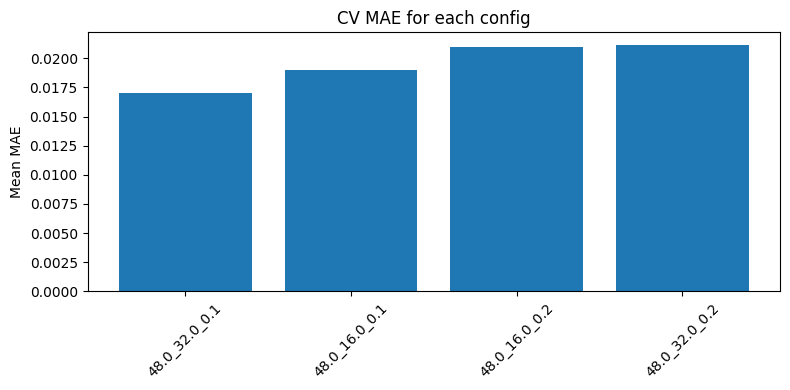

✔ CV plot saved to outputs folder


In [20]:
#plot CV results
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(range(len(res_df)), res_df['mae_mean'])
plt.title("CV MAE for each config")
plt.ylabel("Mean MAE")
plt.xticks(range(len(res_df)),
           [f"{row.seq_len}_{row.units}_{row.dropout}"
            for _, row in res_df.iterrows()],
           rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'cv_metrics.png'))
plt.show()

print("✔ CV plot saved to outputs folder")


Best configuration selected: seq_len      48.000000
units        32.000000
dropout       0.100000
mae_mean      0.017003
rmse_mean     0.025243
Name: 2, dtype: float64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 98s 25ms/step - loss: 0.0500 - mae: 0.1122 - val_loss: 0.0021 - val_mae: 0.0311
Epoch 2/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 138s 24ms/step - loss: 0.0052 - mae: 0.0506 - val_loss: 0.0014 - val_mae: 0.0256
Epoch 3/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 138s 23ms/step - loss: 0.0047 - mae: 0.0479 - val_loss: 0.0012 - val_mae: 0.0246
Epoch 4/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 87s 23ms/step - loss: 0.0046 - mae: 0.0470 - val_loss: 0.0011 - val_mae: 0.0233
Epoch 5/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 87s 23ms/step - loss: 0.0044 - mae: 0.0459 - val_loss: 0.0010 - val_mae: 0.0227
Epoch 6/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 142s 23ms/step - loss: 0.0044 - mae: 0.0457 - val_loss: 0.0012 - val_mae: 0.0237
Epoch 7/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 89s 24ms/step - loss: 0.0043 - mae: 0.0453 - val_loss: 0.0010 - val_mae: 0.0221
Epoch 8/30
3796/3796 ━━━━━━━━━━━━━━━━━━━━ 88s 23ms/step - loss: 0.0043 - mae: 0.0453 - val_loss: 9.1076e-04 - val_mae: 0.0208
Epoch 9/30
3796/3

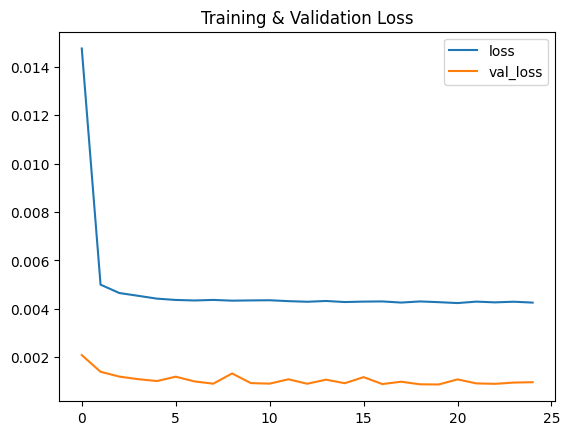

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
✔ Final Test MAE: 0.01613122619936334
✔ Final Test RMSE: 0.02458423519097736


In [21]:
#Train final model using best config
best = res_df.iloc[0]
SEQ_FINAL = int(best['seq_len'])
UNITS_FINAL = int(best['units'])
DROP_FINAL = float(best['dropout'])

print("Best configuration selected:", best)

# Create sequences with final seq_len
Xf, yf = create_sequences(data_scaled, target_idx, seq_len=SEQ_FINAL, horizon=HORIZON)

# 10% test split
test_size = max(int(0.1 * Xf.shape[0]), 50)
X_train_final, y_train_final = Xf[:-test_size], yf[:-test_size]
X_test_final, y_test_final = Xf[-test_size:], yf[-test_size:]

# Build final model
final_model = build_lstm(SEQ_FINAL, Xf.shape[2], units=UNITS_FINAL, dropout=DROP_FINAL)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = final_model.fit(
    X_train_final, y_train_final,
    validation_split=0.1,
    epochs=30,          # fast version (instead of 100)
    batch_size=32,
    callbacks=[es],
    verbose=1
)

# Save model
final_model.save(os.path.join(BASE, 'outputs', 'final_lstm.h5'))

# Save training loss curve
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training & Validation Loss")
plt.savefig(os.path.join(BASE, 'outputs', 'loss_curve.png'))
plt.show()

# Evaluate on test set
pred_test = final_model.predict(X_test_final).ravel()
mae_test = mean_absolute_error(y_test_final, pred_test)
rmse_test = rmse(y_test_final, pred_test)

print("Final Test MAE:", mae_test)
print("Final Test RMSE:", rmse_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


  0%|          | 0/3 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


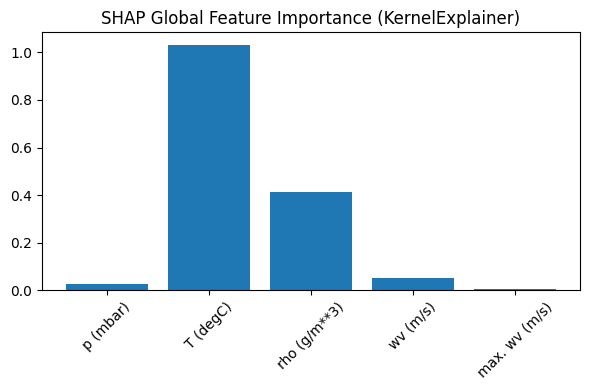

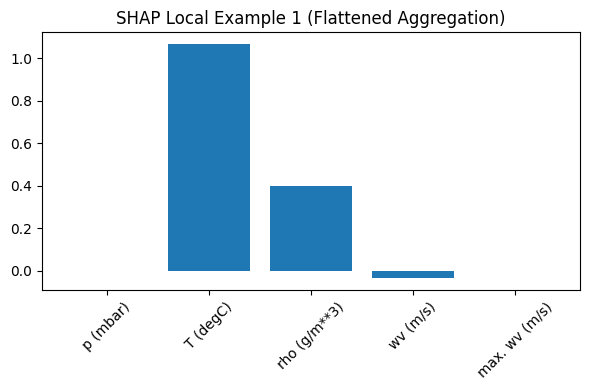

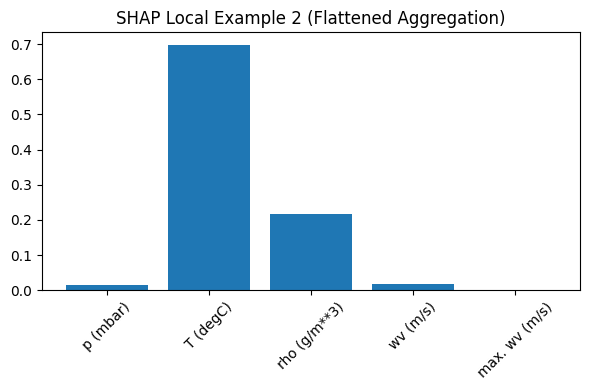

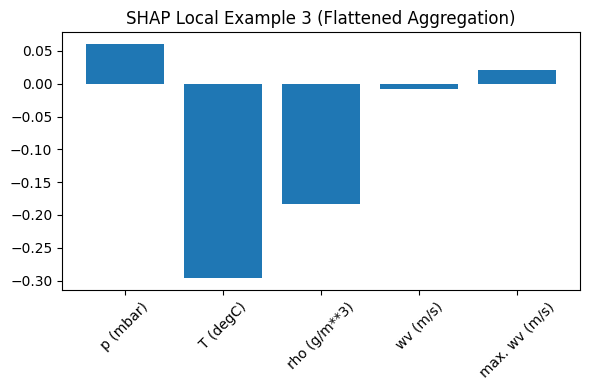

SHAP explainability completed successfully


In [23]:
#SHAP Explainability (KernelExplainer - TensorFlow 2.12 Compatible)
import shap
import numpy as np
import matplotlib.pyplot as plt

# ---- Prepare background sample (smaller = faster) ----
bg_size = min(50, X_train_final.shape[0])
background = X_train_final[np.random.choice(X_train_final.shape[0], bg_size, replace=False)]

# Reshape background for KernelExplainer: flatten each sequence
background_flat = background.reshape(background.shape[0], -1)

# ---- Prepare test samples ----
test_idxs = [0, len(X_test_final)//2, -1]  # 3 examples
test_samples = X_test_final[test_idxs]
test_samples_flat = test_samples.reshape(test_samples.shape[0], -1)

# ---- Define prediction function for SHAP ----
def model_predict(flat_input):
    reshaped = flat_input.reshape(flat_input.shape[0], SEQ_FINAL, len(FEATURES))
    return final_model.predict(reshaped).ravel()

# ---- KernelExplainer ----
explainer = shap.KernelExplainer(model_predict, background_flat)

# compute SHAP values for the 3 test points
shap_values = explainer.shap_values(test_samples_flat, nsamples=200)  # keep low for speed
shap_arr = np.array(shap_values)  # shape: (3, flattened_dim)

# reshape back to (3, seq_len, n_features)
shap_arr = shap_arr.reshape(3, SEQ_FINAL, len(FEATURES))

# ---- GLOBAL importance (sum abs across samples + time) ----
abs_agg = np.mean(np.abs(shap_arr), axis=0)      # shape: (seq_len, features)
feature_importance = np.sum(abs_agg, axis=0)     # shape: (features,)

plt.figure(figsize=(6,4))
plt.bar(FEATURES, feature_importance)
plt.xticks(rotation=45)
plt.title("SHAP Global Feature Importance (KernelExplainer)")
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'shap_summary.png'))
plt.show()

# ---- LOCAL importance: each example saved separately ----
for i, idx in enumerate(test_idxs):
    local_vals = np.sum(shap_arr[i], axis=0)   # sum over time-axis
    plt.figure(figsize=(6,4))
    plt.bar(FEATURES, local_vals)
    plt.xticks(rotation=45)
    plt.title(f"SHAP Local Example {i+1} (Flattened Aggregation)")
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, 'outputs', f'shap_local_{i+1}.png'))
    plt.show()

# Save raw SHAP values
np.save(os.path.join(BASE, 'outputs', 'shap_values.npy'), shap_arr)

print("SHAP explainability completed successfully")


In [24]:
#List all outputs
out_dir = os.path.join(BASE, 'outputs')
print("All generated files in:", out_dir)
for f in os.listdir(out_dir):
    print("-", f)


All generated files in: /content/drive/My Drive/TimeSeries_LSTM_Project/outputs
- scaler.save
- metrics_summary.csv
- cv_metrics.png
- final_lstm.h5
- loss_curve.png
- shap_summary.png
- shap_local_1.png
- shap_local_2.png
- shap_local_3.png
- shap_values.npy
